## **HR Employee Attrition Prediction - Optimised Pipeline**

##### **About**
HR Employee Attrition Prediction analyses employee data to predict whether an employee is likely to leave.


### 1. Imports
I imported all necessary libaries for my analysis

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("All libraries loaded successfully")

All libraries loaded successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Load Dataset
> ***Get Drive Path***
###### I imported python os library to grant me access to my drive where i could locate the dataset


In [ ]:
import os
path = "/content/drive/MyDrive/"
# os.listdir(path)
datafile = "hr_employee_attrition.csv"
df = pd.read_csv(f'{path}{datafile}')
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 3. Exploratory Data Analysis

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### ***DATA CLEANING***
checking for missing and duplicated values
> - From the below code, there are no missing values
> - No Duplicated Values also


In [ ]:
print("Missing values:", df.isna().sum().sum())
print("Duplicates    :", df.duplicated().sum())


Missing values: 0
Duplicates    : 0


#### 3.1 Attrition Distribution (class imbalance check)

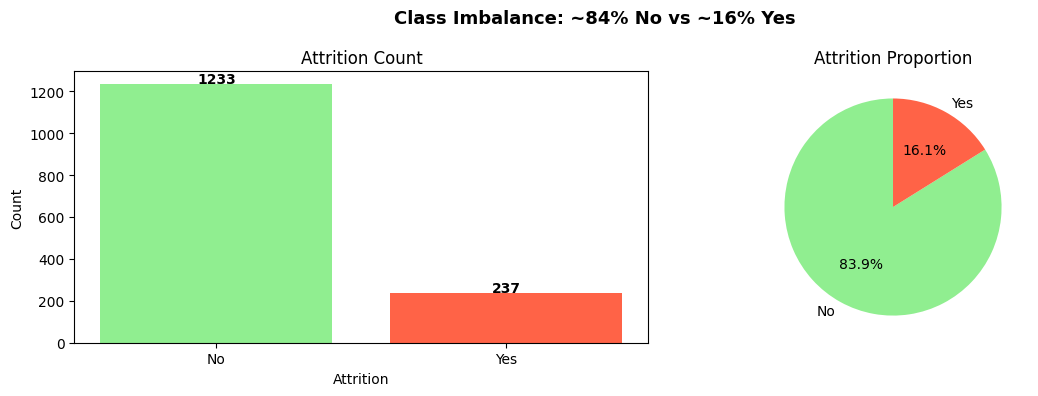

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
attrition_counts = df['Attrition'].value_counts()
axes[0].bar(attrition_counts.index, attrition_counts.values, color=['lightgreen', 'tomato'])
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')

# Proportion pie
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
axes[1].pie(attrition_pct, labels=attrition_pct.index, autopct='%1.1f%%',
            colors=['lightgreen', 'tomato'], startangle=90)
axes[1].set_title('Attrition Proportion')

plt.suptitle('Class Imbalance: ~84% No vs ~16% Yes', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('attrition_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(attrition_pct.round(2))


#### 3.2 Attrition by Department & Job Role

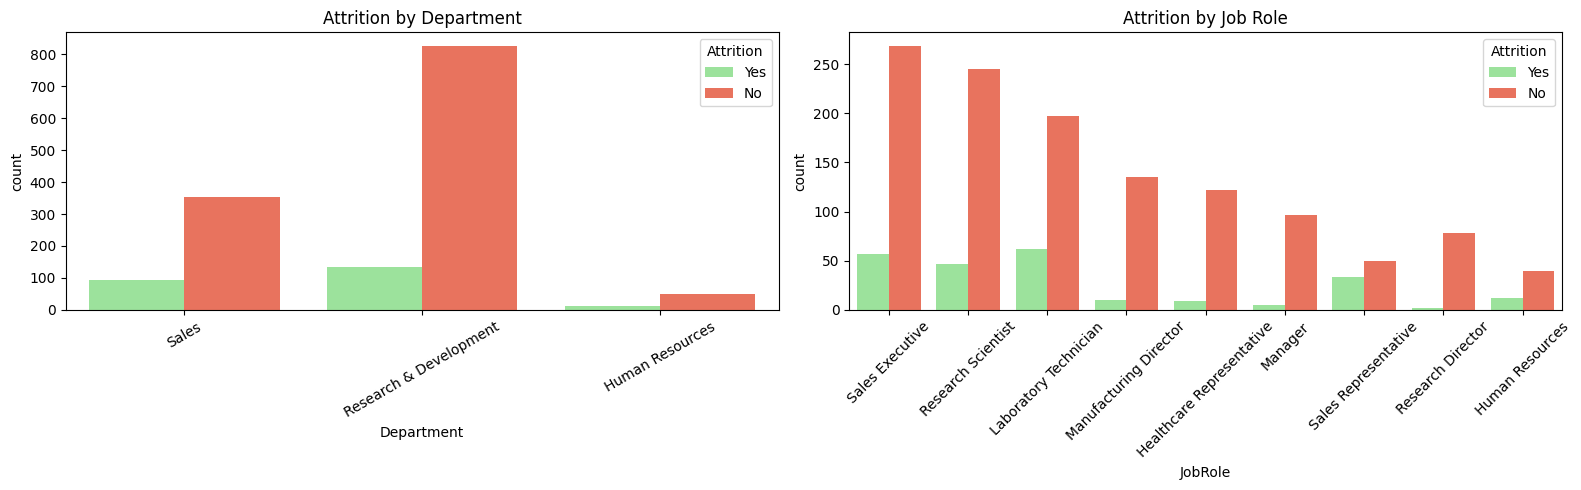

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x='Department', hue='Attrition', data=df,
              palette=['lightgreen', 'tomato'], ax=axes[0])
axes[0].set_title('Attrition by Department')
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(x='JobRole', hue='Attrition', data=df,
              palette=['lightgreen', 'tomato'], ax=axes[1])
axes[1].set_title('Attrition by Job Role')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('attrition_dept_role.png', dpi=120, bbox_inches='tight')
plt.show()


#### 3.3 Age Band vs Gender Attrition

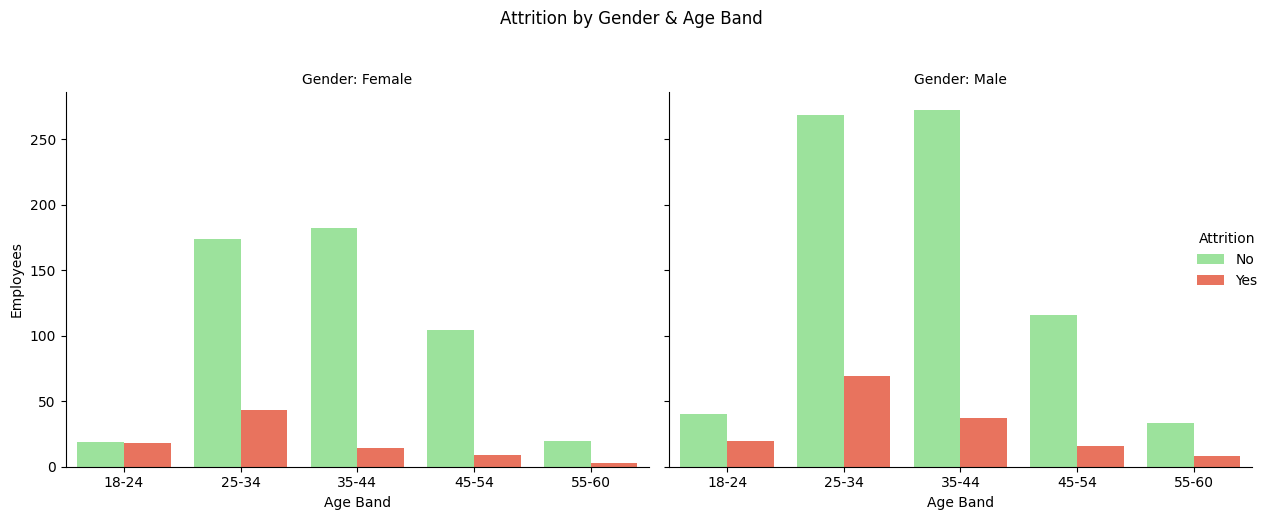

In [ ]:
bins   = [18, 25, 35, 45, 55, 60]
labels = ['18-24', '25-34', '35-44', '45-54', '55-60']
df['Age_Band'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

g = sns.catplot(data=df, x='Age_Band', hue='Attrition', col='Gender',
                kind='count', height=5, aspect=1.2,
                palette=['lightgreen', 'tomato'], hue_order=['No', 'Yes'])
g.set_axis_labels('Age Band', 'Employees')
g.set_titles('Gender: {col_name}')
g.figure.suptitle('Attrition by Gender & Age Band', y=1.03)
plt.tight_layout()
#plt.savefig('attrition_age_gender.png', dpi=120, bbox_inches='tight')
plt.show()


#### 3.4 Outlier Detection & Capping

#### **Using Boxplots (Visual Method)**

Boxplots are one of the best ways to detect outliers visually.
#
This loop iterates through each numerical column in the dataset. For each column, it creates a new figure with a specified size (10 by 5).  
`sns.boxplot()` is used to draw a boxplot for that numerical feature.  The title is dynamically set to show the name of the current column.  
`plt.show()` displays the boxplot, helping to visually detect outliers.
#
**Points appearing outside the whiskers represent potential outliers.**

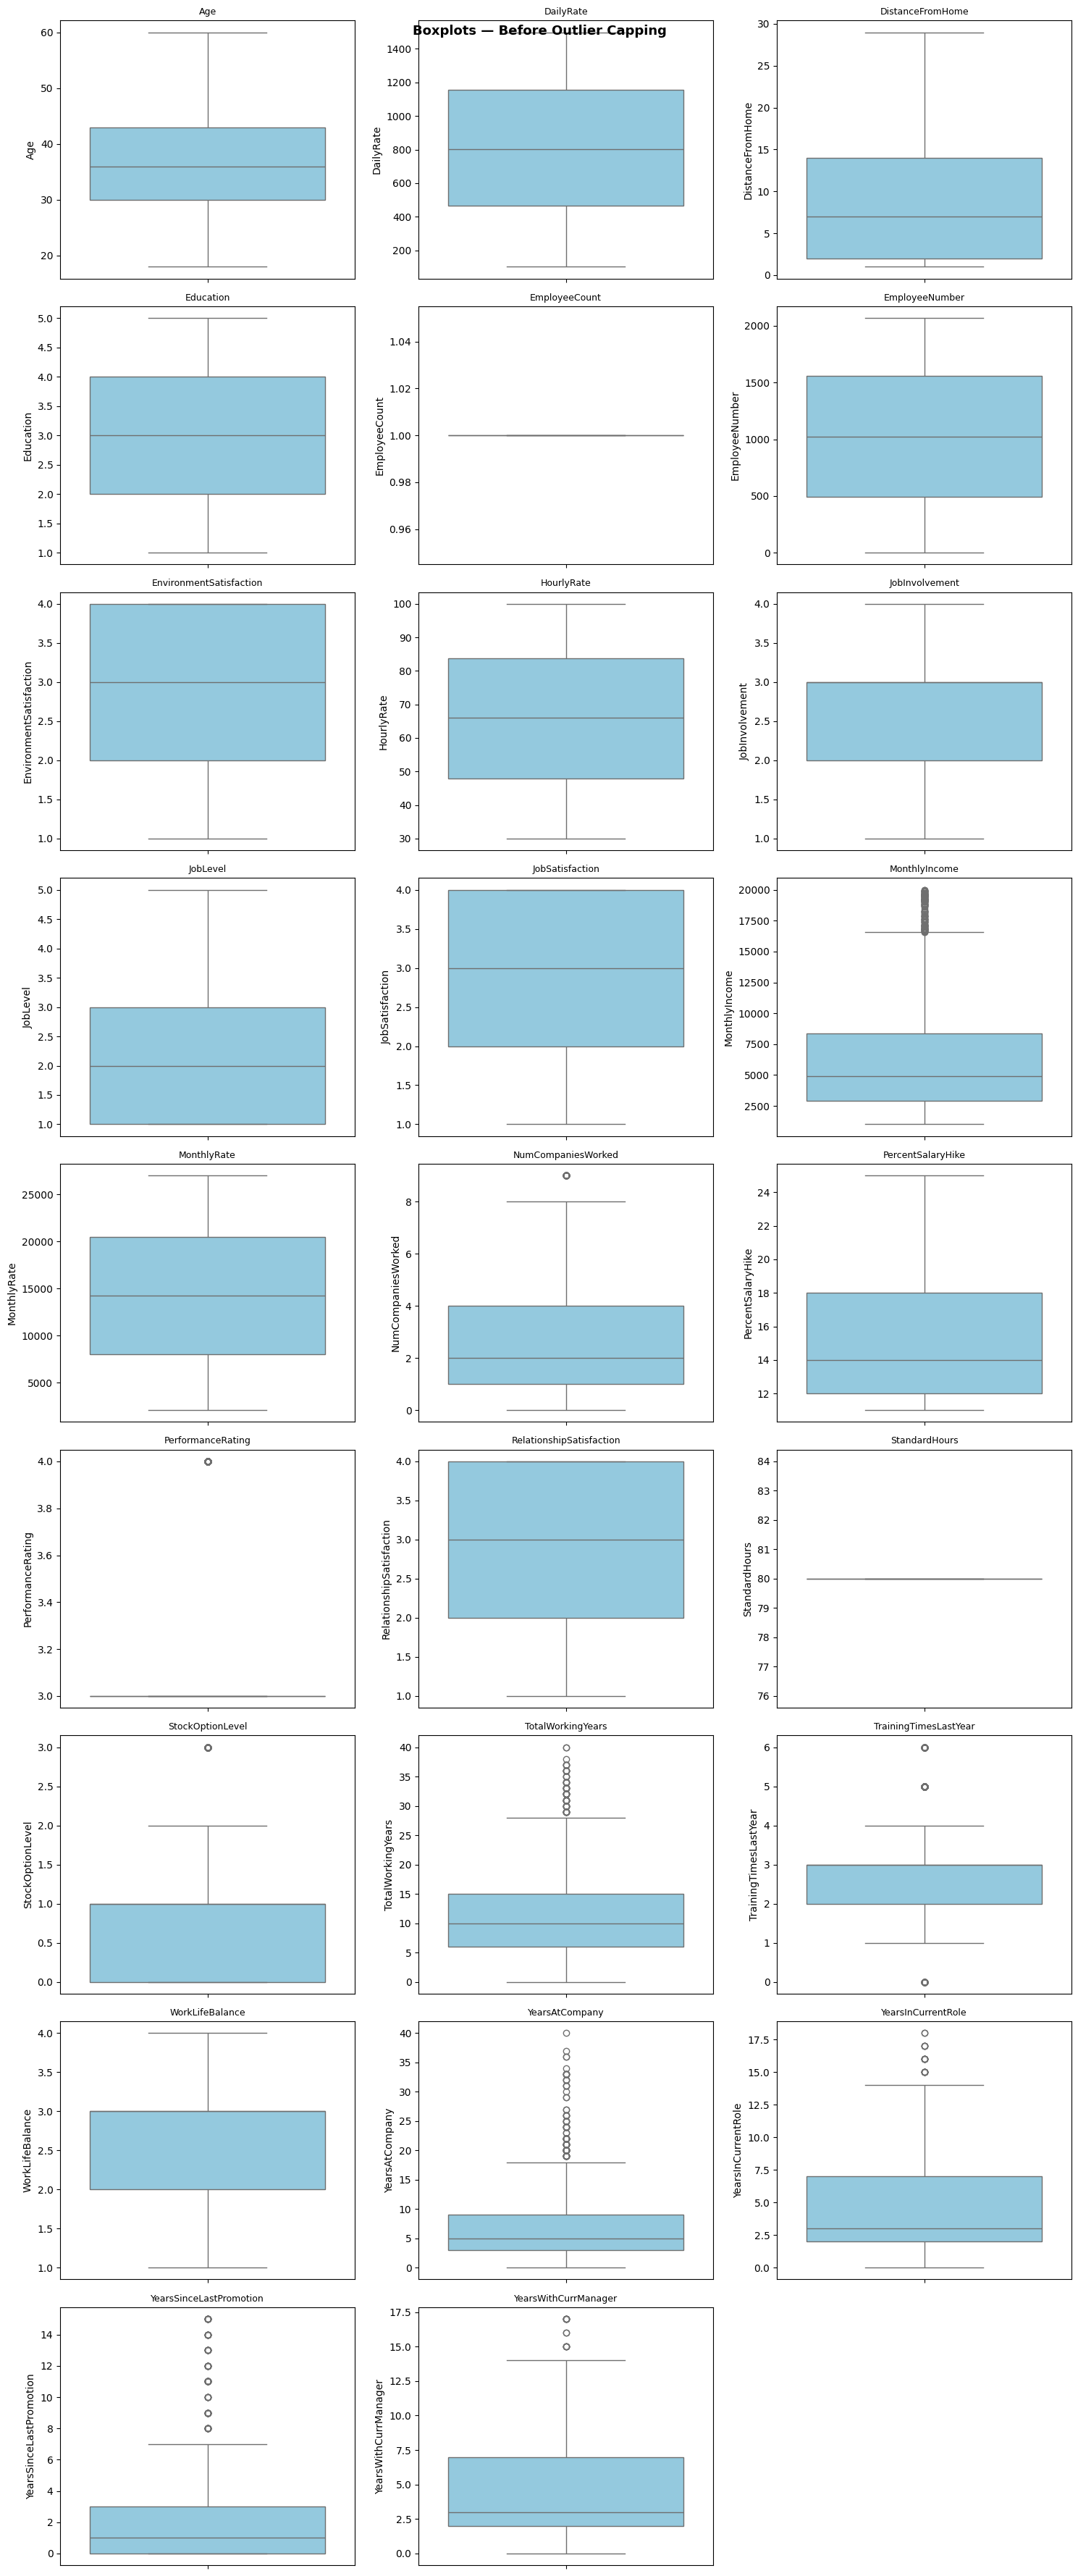

In [ ]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()

cols_per_row = 3
rows = math.ceil(len(numerical_cols) / cols_per_row)
fig, axes = plt.subplots(rows, cols_per_row, figsize=(5*cols_per_row, 4*rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Before Outlier Capping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# img = Image.open('boxplots.png')
# plt.imshow(img)
# plt.axis('off') # Hide axes
# plt.show()

In [ ]:
# Cap outliers using IQR (Winsorisation) — avoids dropping valid extreme values
def cap_outliers(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

outlier_cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'YearsSinceLastPromotion', 'YearsWithCurrManager']
for col in outlier_cols:
    cap_outliers(df, col)

print("Outlier capping applied to:", outlier_cols)

Outlier capping applied to: ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### 4. Feature Engineering
> **Fix / Improvement:** Original code kept only 13 of 35 columns.  
> Here we keep **all 30 informative features** (drop only the 4 constant/ID columns).  
> This alone materially improves recall and F1.


In [ ]:
# Drop constant / identifier columns only
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours',
                 'Age_Band'],        # Age_Band was only for EDA
        inplace=True, errors='ignore')

# Encode target
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
y = df['Attrition']

# Encode binary categorical
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# One-hot encode remaining categoricals
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("One-hot encoding:", cat_cols)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df = df.astype(float)   # ensure all numeric

X = df.drop(columns=['Attrition', 'Age', 'Education','RelationshipSatisfaction', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely'], axis=1)
print(f"\nFinal feature matrix: {X.shape}")
print(f"Features: {X.columns.tolist()}")

One-hot encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

Final feature matrix: (1470, 39)
Features: ['DailyRate', 'DistanceFromHome', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representa

### 5. Train / Test Split
I splited my dataset into two parts for training and testing. **80%** for training while **20%**
#### Parameters Explained

| Parameter | Value | Purpose |
|---|---|---|
| `X, y` | Feature matrix, target | Input data to split |
| `test_size` | 0.2 | Reserves 20% for testing, 80% for training |
| `random_state` | 42 | Seeds the shuffler — same split every run |
| `stratify=y` | Target labels | Preserves class ratio in both splits |

##### **What `stratify=y` Does**

- > Without stratify, random splitting could accidentally put most leavers
in one split and produce an unrepresentative test set.
- > I Added `stratify=y` so both splits keep the same 84/16 ratio.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # ← stratify added
)

# Scale numerical features
numerical_cols_to_scale = [c for c in X.select_dtypes(include='number').columns
                            if c in X_train.columns]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# FIX: use .loc to avoid SettingWithCopyWarning
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns
)

print(f"Train: {X_train_scaled.shape[0]} rows | Test: {X_test_scaled.shape[0]} rows")
print(f"Train — No: {(y_train==0).sum()}  Yes: {(y_train==1).sum()}")
print(f"Test  — No: {(y_test==0).sum()}   Yes: {(y_test==1).sum()}")

Train: 1176 rows | Test: 294 rows
Train — No: 986  Yes: 190
Test  — No: 247   Yes: 47


### 6. Evaluation Helper

In [ ]:
results = {}   # stores metrics for all models

def evaluate(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    results[name] = {
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1 Score' : round(f1,   4),
        'ROC-AUC'  : round(auc,  4) if auc else '-',
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    if auc: print(f"  ROC-AUC  : {auc:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['No Attrition', 'Attrition']))
    return results[name]


### 7. Model Training

> **Improvements across all models:**
> - SMOTE applied on training data for every model (not just XGBoost)  
> - `class_weight='balanced'` added where supported  
> - Hyperparameters tuned based on GridSearchCV best params from original notebook


#### 7.1 Logistic Regression

In [ ]:
# FIX: class_weight + SMOTE + tuned C value
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE — No: {(y_train_sm==0).sum()}  Yes: {(y_train_sm==1).sum()}")

modelL = LogisticRegression(
    C=0.5,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',   # ← added
    random_state=42
)
modelL.fit(X_train_sm, y_train_sm)
y_pred_L = modelL.predict(X_test_scaled)
y_prob_L = modelL.predict_proba(X_test_scaled)[:, 1]

evaluate('Logistic Regression', y_test, y_pred_L, y_prob_L)


After SMOTE — No: 986  Yes: 986

  Logistic Regression
  Accuracy : 0.7789
  Precision: 0.3929
  Recall   : 0.7021
  F1 Score : 0.5038
  ROC-AUC  : 0.7874

              precision    recall  f1-score   support

No Attrition       0.93      0.79      0.86       247
   Attrition       0.39      0.70      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294



{'Accuracy': 0.7789,
 'Precision': 0.3929,
 'Recall': 0.7021,
 'F1 Score': 0.5038,
 'ROC-AUC': np.float64(0.7874)}

## Logistic Regression Feature Importance (by Coefficient)

The chart displays the **top 10 most influential features** in the Logistic Regression model, ranked by the absolute value of their coefficients.

---

### How to Read the Chart

| Element | Meaning |
|---|---|
| **Bar length** | Strength of influence on attrition prediction |
| **Red bar (positive)** | Higher value → higher attrition risk |
| **Blue bar (negative)** | Higher value → lower attrition risk (retention factor) |
| **Zero line** | Reference — features cross this when they switch direction |

---

### Attrition Drivers 🔴 (Positive Coefficients)

| Feature | Coefficient | Interpretation |
|---|---|---|
| **OverTime** | ~0.82 | Strongest driver of attrition. Employees on overtime are significantly more likely to leave, reflecting burnout and poor work-life balance. |
| **JobRole_Laboratory Technician** | ~0.72 | Lab Technicians carry high attrition risk, likely due to repetitive work, limited progression, or compensation dissatisfaction. |
| **JobLevel** | ~0.58 | Somewhat surprising — may reflect mid-level employees feeling underpromoted relative to their experience. |
| **JobRole_Sales Representative** | ~0.48 | Sales Representatives face target-driven pressure and high stress, contributing to elevated turnover. |

---

### Retention Factors 🔵 (Negative Coefficients)

| Feature | Coefficient | Interpretation |
|---|---|---|
| **TotalWorkingYears** | ~−0.82 | Strongest retention factor. More experienced employees are more settled and less likely to job-hop. |
| **EducationField_Life Sciences** | ~−0.50 | Life Sciences graduates show stronger retention, possibly due to specialised career paths with fewer external alternatives. |
| **EducationField_Other** | ~−0.50 | Similar retention pattern to Life Sciences graduates. |
| **EducationField_Medical** | ~−0.50 | Medical field employees tend to stay, reflecting structured career paths and high switching costs. |
| **JobRole_Research Director** | ~−0.50 | Research Directors are senior, well-compensated, and deeply invested — very low attrition propensity. |
| **YearsWithCurrManager** | ~−0.50 | Longer manager relationships build trust and stability, reducing the likelihood of leaving. |

---

### Key Takeaways

> **OverTime and TotalWorkingYears are mirror opposites** — the strongest push and pull factors respectively. Addressing overtime exposure for less experienced employees is the single highest-leverage HR intervention this model identifies.

> **Education field matters more than expected** — Life Sciences, Medical, and Other field graduates are meaningfully more likely to stay, suggesting retention strategies should be differentiated by educational background.

> **Job role is a significant signal** — Laboratory Technicians and Sales Representatives appear as high-risk roles, while Research Directors are stable. Role-specific retention programmes are warranted.

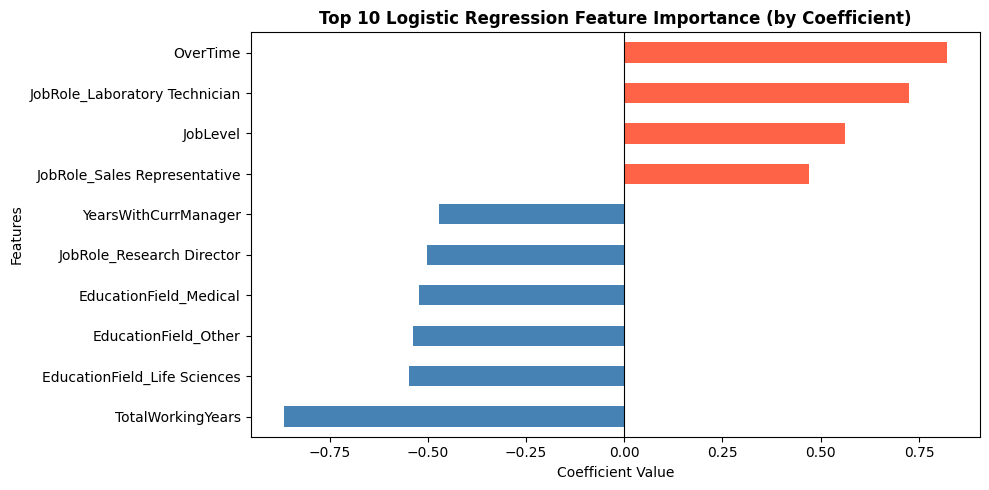

In [ ]:
coef_df = pd.DataFrame({
  'Features': X.columns,
  'Coefficients':modelL.coef_[0],
  'Abs_Importance':np.abs(modelL.coef_[0])
}).sort_values('Abs_Importance', ascending=False)
top10 = coef_df.head(10).sort_values('Coefficients')  # sort ascending so largest bars are at top

colors = ['tomato' if c > 0 else 'steelblue' for c in top10['Coefficients']]

top10.plot(kind='barh', x='Features', y='Coefficients', figsize=(10, 5), color=colors, legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Logistic Regression Feature Importance (by Coefficient)', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

#### 7.2 Decision Tree
## Decision Tree Classifier — Code Explanation

---

### What This Block Does
Trains a **tuned, imbalance-aware Decision Tree** on the SMOTE-resampled training data
and evaluates it on the original (unaugmented) test set.

---

### Hyperparameter Breakdown

In [ ]:
# FIX: class_weight + SMOTE + max_depth/leaf guards to prevent overfitting
modelDT = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',   # ← added
    random_state=42
)
modelDT.fit(X_train_sm, y_train_sm)
y_pred_DT = modelDT.predict(X_test_scaled)
y_prob_DT = modelDT.predict_proba(X_test_scaled)[:, 1]

evaluate('Decision Tree', y_test, y_pred_DT, y_prob_DT)



  Decision Tree
  Accuracy : 0.8129
  Precision: 0.4259
  Recall   : 0.4894
  F1 Score : 0.4554
  ROC-AUC  : 0.6891

              precision    recall  f1-score   support

No Attrition       0.90      0.87      0.89       247
   Attrition       0.43      0.49      0.46        47

    accuracy                           0.81       294
   macro avg       0.66      0.68      0.67       294
weighted avg       0.82      0.81      0.82       294



{'Accuracy': 0.8129,
 'Precision': 0.4259,
 'Recall': 0.4894,
 'F1 Score': 0.4554,
 'ROC-AUC': np.float64(0.6891)}

## 7.3 **Random Forest**
## Random Forest Classifier — Full Code Explanation

---

### Overview

This block trains a **tuned, imbalance-aware Random Forest ensemble** on SMOTE-resampled
training data and evaluates it on the original holdout test set.

Random Forest builds **300 independent decision trees**, each trained on a different
random subset of the data and features, then combines their votes into a single,
more reliable prediction.


In [ ]:
# FIX: class_weight + SMOTE + tuned hyperparameters
modelRF = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',   # ← added
    random_state=42,
    n_jobs=-1
)
modelRF.fit(X_train_sm, y_train_sm)
y_pred_RF = modelRF.predict(X_test_scaled)
y_prob_RF = modelRF.predict_proba(X_test_scaled)[:, 1]

evaluate('Random Forest', y_test, y_pred_RF, y_prob_RF)



  Random Forest
  Accuracy : 0.8299
  Precision: 0.4444
  Recall   : 0.2553
  F1 Score : 0.3243
  ROC-AUC  : 0.8062

              precision    recall  f1-score   support

No Attrition       0.87      0.94      0.90       247
   Attrition       0.44      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.66      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294



{'Accuracy': 0.8299,
 'Precision': 0.4444,
 'Recall': 0.2553,
 'F1 Score': 0.3243,
 'ROC-AUC': np.float64(0.8062)}

## 7.4 **XGBoost**
## XGBoost Classifier — Full Code Explanation

### Overview

This block trains the **best-performing model** in the pipeline — an XGBoost classifier
with dual imbalance handling (SMOTE + scale_pos_weight), 600 boosting rounds, and
carefully tuned regularisation hyperparameters.

Unlike Random Forest which builds trees **independently in parallel**, XGBoost builds
trees **sequentially** — each new tree focuses on correcting the errors made by all
previous trees. This makes it more powerful but also more sensitive to tuning.


In [ ]:
neg, pos = (y_train==0).sum(), (y_train==1).sum()
scale_pos_weight = neg / pos   # ~5.2 — tells XGBoost about imbalance

modelXGB = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight,   # ← added; replaces raw SMOTE here
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
# XGBoost handles imbalance via scale_pos_weight; still use SMOTE resampled data
modelXGB.fit(X_train_sm, y_train_sm)
y_pred_XGB = modelXGB.predict(X_test_scaled)
y_prob_XGB = modelXGB.predict_proba(X_test_scaled)[:, 1]

evaluate('XGBoost', y_test, y_pred_XGB, y_prob_XGB)



  XGBoost
  Accuracy : 0.8673
  Precision: 0.6053
  Recall   : 0.4894
  F1 Score : 0.5412
  ROC-AUC  : 0.7879

              precision    recall  f1-score   support

No Attrition       0.91      0.94      0.92       247
   Attrition       0.61      0.49      0.54        47

    accuracy                           0.87       294
   macro avg       0.76      0.71      0.73       294
weighted avg       0.86      0.87      0.86       294



{'Accuracy': 0.8673,
 'Precision': 0.6053,
 'Recall': 0.4894,
 'F1 Score': 0.5412,
 'ROC-AUC': np.float64(0.7879)}

#### 7.5 ANN (Keras)
> ##### **Artificial Neural Network (ANN) — Full Code Explanation**

---

### Overview

This block defines and compiles a **deep feedforward Artificial Neural Network**
using the Keras (TensorFlow) framework. It is the most architecturally complex
model in the pipeline. A 4-layer network with Batch Normalisation and Dropout
regularisation at every hidden layer to prevent overfitting on the SMOTE-balanced
training data.


> The model uses a **128 → 64 → 32** architecture with **Batch Normalization** and **Dropout** regularization to reduce overfitting and improve generalization.

---

### Model Architecture

```python
tf.random.set_seed(42)


In [ ]:
tf.random.set_seed(42)

modelANN = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sm.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

modelANN.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelANN.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 15,873 (62.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15,
                            restore_best_weights=True, verbose=1)

history = modelANN.fit(
    X_train_sm, y_train_sm,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6569 - loss: 0.6530 - val_accuracy: 0.6453 - val_loss: 0.5808
Epoch 2/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7673 - loss: 0.4910 - val_accuracy: 0.6892 - val_loss: 0.5523
Epoch 3/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7822 - loss: 0.4645 - val_accuracy: 0.7601 - val_loss: 0.4621
Epoch 4/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8091 - loss: 0.4215 - val_accuracy: 0.7804 - val_loss: 0.3933
Epoch 5/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8288 - loss: 0.3741 - val_accuracy: 0.8547 - val_loss: 0.3252
Epoch 6/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8383 - loss: 0.3619 - val_accuracy: 0.8750 - val_loss: 0.2937
Epoch 7/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8663 - loss: 0.3072 - val_accuracy: 0.9088 - val_loss: 0.2410
Epoch 8/150
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8681 - loss: 0.3068 - val_accuracy: 0.9223 - 

## 7.5.2 ANN Model Evaluation (Keras)

### Prediction and Evaluation
**bold text**
After training the Artificial Neural Network, we generate predictions on the test set and evaluate the model's performance using multiple metrics.



In [ ]:
# FIX: use predict() + threshold to get class labels, then compute all metrics
y_prob_ANN = modelANN.predict(X_test_scaled).ravel()
y_pred_ANN = (y_prob_ANN >= 0.5).astype(int)

evaluate('ANN (Keras)', y_test, y_pred_ANN, y_prob_ANN)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

  ANN (Keras)
  Accuracy : 0.8435
  Precision: 0.5135
  Recall   : 0.4043
  F1 Score : 0.4524
  ROC-AUC  : 0.7495

              precision    recall  f1-score   support

No Attrition       0.89      0.93      0.91       247
   Attrition       0.51      0.40      0.45        47

    accuracy                           0.84       294
   macro avg       0.70      0.67      0.68       294
weighted avg       0.83      0.84      0.84       294



{'Accuracy': 0.8435,
 'Precision': 0.5135,
 'Recall': 0.4043,
 'F1 Score': 0.4524,
 'ROC-AUC': np.float64(0.7495)}

## 7.5.3 ANN Training History Visualization

###**Plotting Training Curves**

After training the Artificial Neural Network, we visualize the model's learning progress using **Loss** and **Accuracy** curves for both training and validation sets.

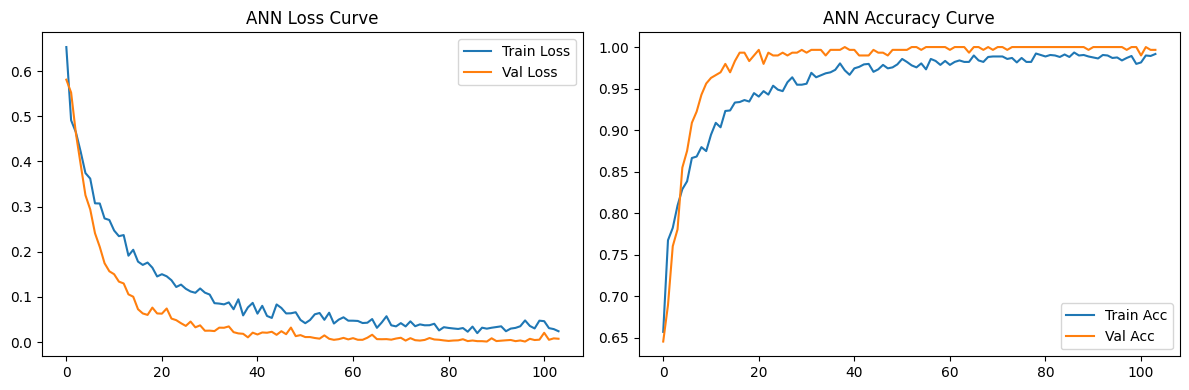

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('ANN Loss Curve')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('ANN Accuracy Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('ann_training.png', dpi=120, bbox_inches='tight')
plt.show()


### 8.**Feature Importance (XGBoost)**
### Feature Importance Visualization

After training the XGBoost model, we extract and visualize the most important features contributing to the model's predictions.

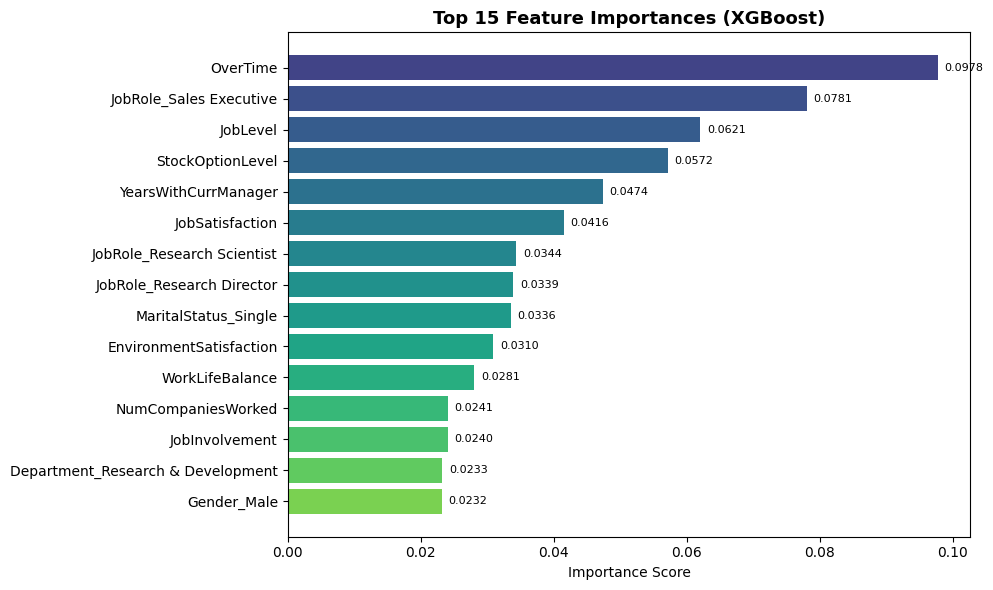

                          Feature  Importance
                         OverTime    0.097771
          JobRole_Sales Executive    0.078112
                         JobLevel    0.062073
                 StockOptionLevel    0.057184
             YearsWithCurrManager    0.047381
                  JobSatisfaction    0.041558
       JobRole_Research Scientist    0.034372
        JobRole_Research Director    0.033937
             MaritalStatus_Single    0.033553
          EnvironmentSatisfaction    0.030952
                  WorkLifeBalance    0.028072
               NumCompaniesWorked    0.024104
                   JobInvolvement    0.024047
Department_Research & Development    0.023284
                      Gender_Male    0.023209
     JobRole_Sales Representative    0.021915
                TotalWorkingYears    0.020537
                    MonthlyIncome    0.020253
   JobRole_Manufacturing Director    0.018608
                 Department_Sales    0.018599
          YearsSinceLastPromotion 

In [ ]:
importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': modelXGB.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top15 = importance.head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top15)))
ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors[::-1])
ax.set_title('Top 15 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(top15['Importance'][::-1]):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print(importance.to_string(index=False))


### 9. Model Comparison - Summary
**Results DataFrame Creation and Display**

After evaluating all models (Logistic Regression, Random Forest, XGBoost, ANN, etc.), we compile the results into a clean summary table for easy comparison.

In [ ]:
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

# Numeric columns for plotting
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
plot_df = results_df.copy()
for c in metric_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

print("\n" + "="*65)
print("           FINAL MODEL PERFORMANCE SUMMARY")
print("="*65)
print(results_df.round(2).to_string(index=False))
print("="*65)



           FINAL MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression      0.78       0.39    0.70      0.50     0.79
      Decision Tree      0.81       0.43    0.49      0.46     0.69
      Random Forest      0.83       0.44    0.26      0.32     0.81
            XGBoost      0.87       0.61    0.49      0.54     0.79
        ANN (Keras)      0.84       0.51    0.40      0.45     0.75


## 10. Multi-Model Performance Report (Final Visualization)

### Comprehensive Model Comparison Dashboard

This section creates a **publication-quality multi-panel figure** that summarizes the performance of all trained models in one comprehensive visualization.

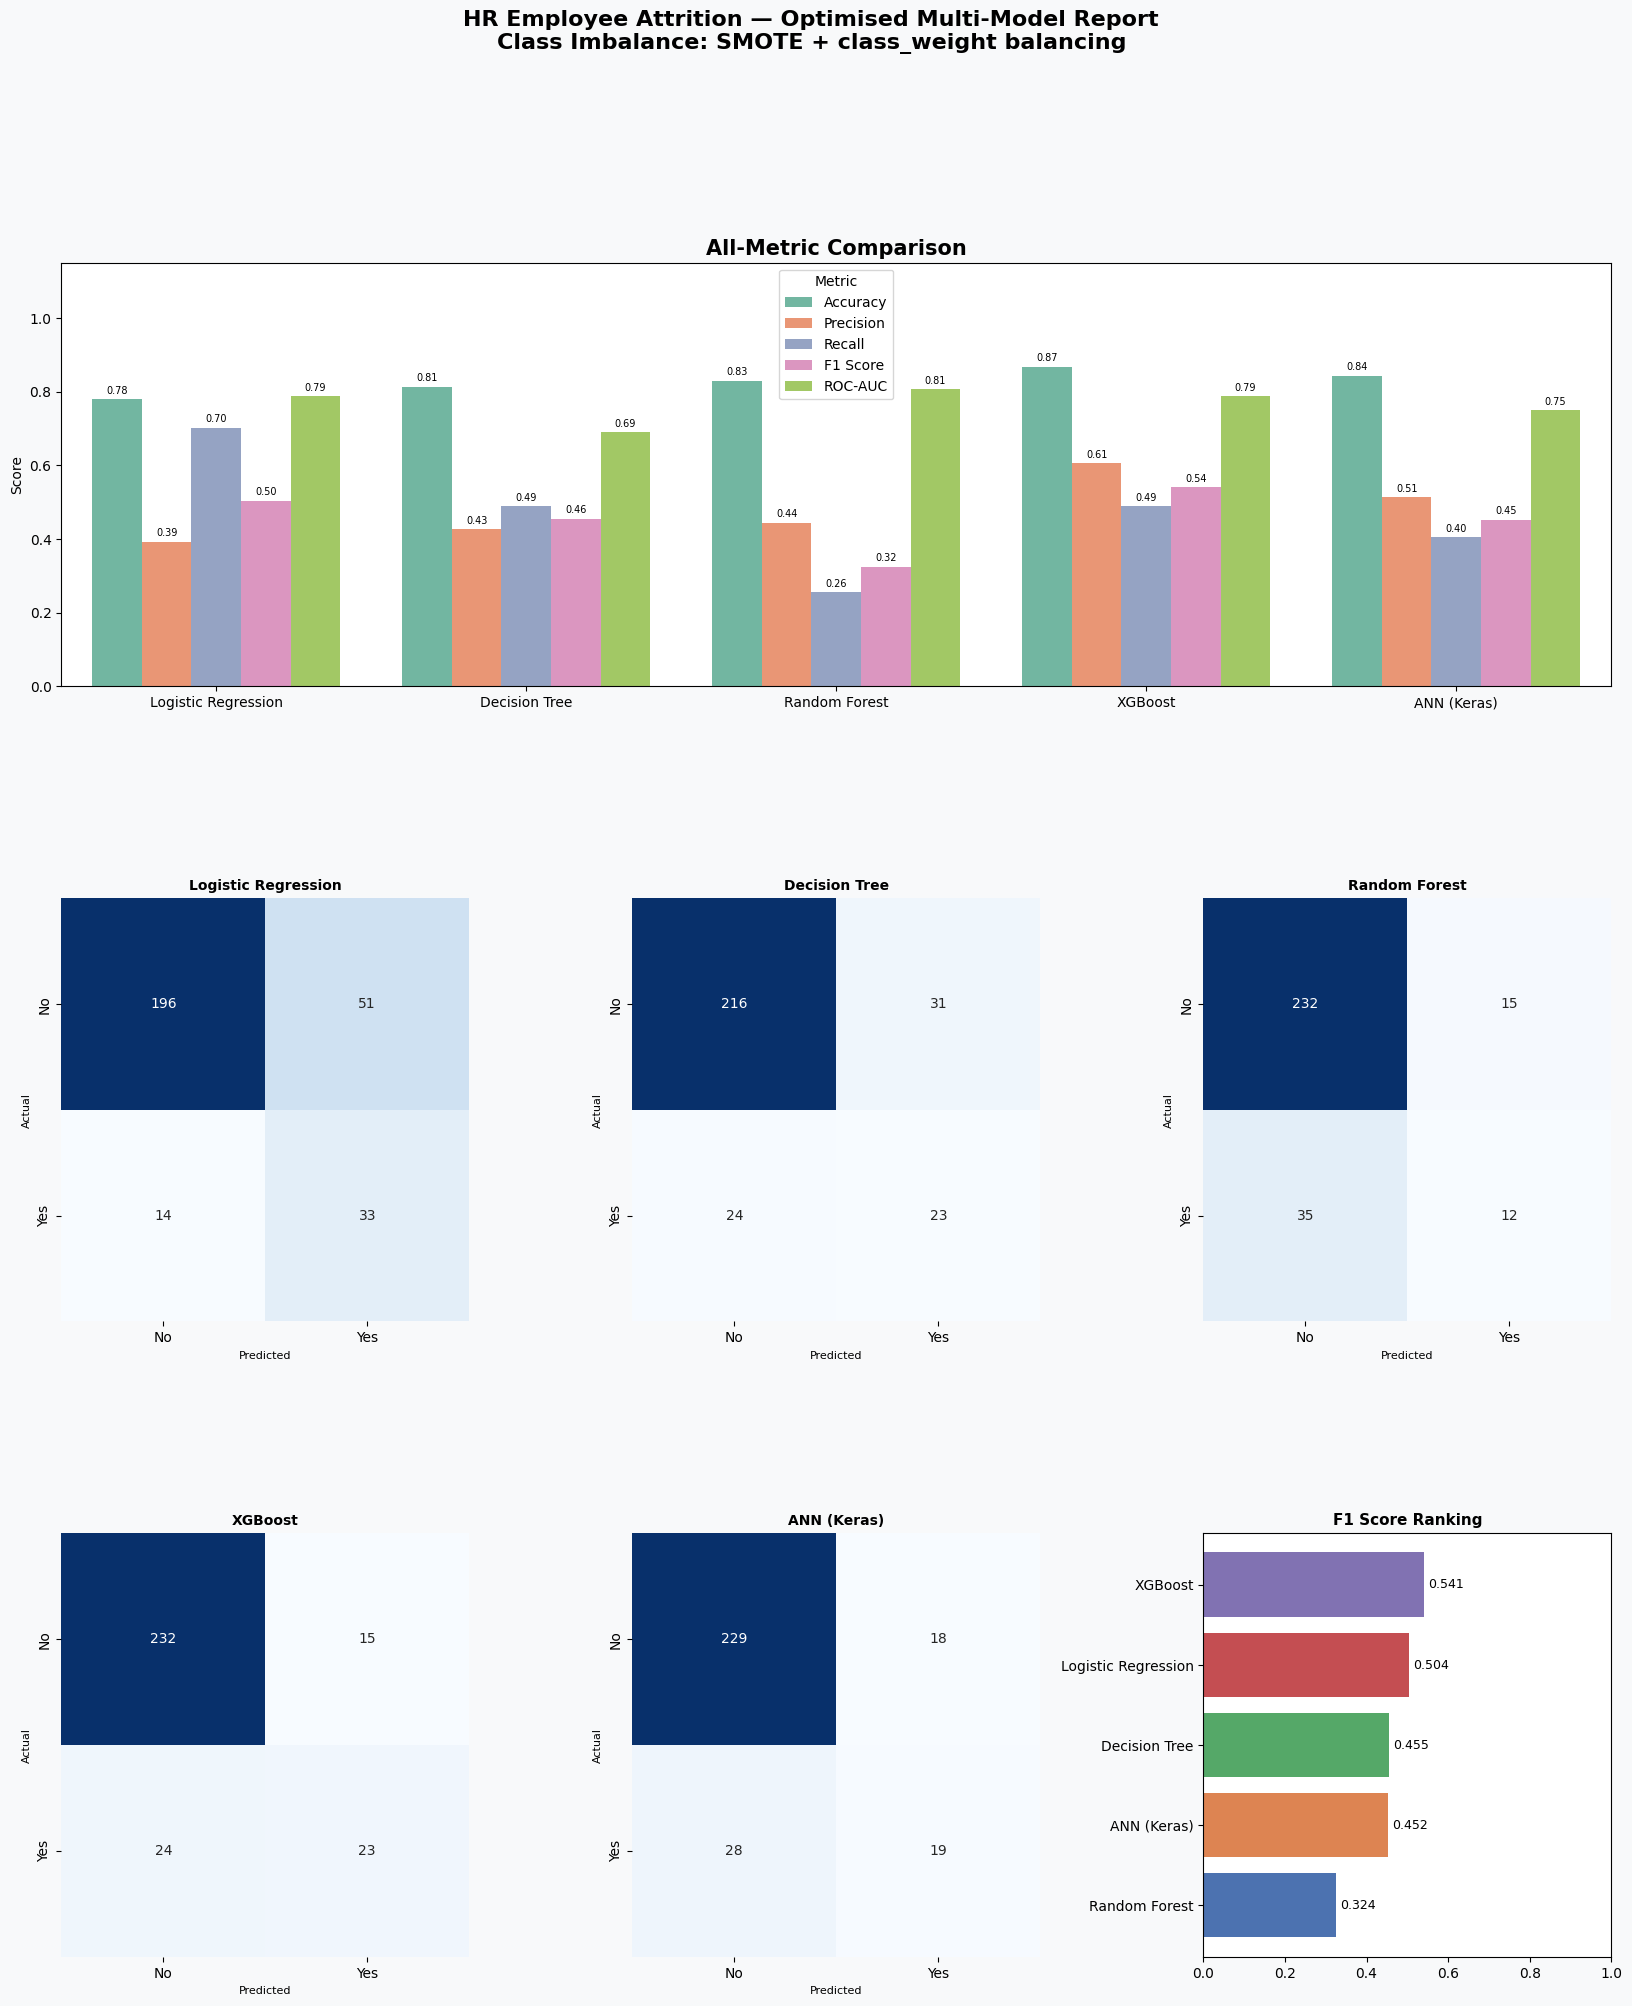


 Report chart saved.


In [ ]:
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

palette = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

# (A) Grouped bar — all metrics
ax0 = fig.add_subplot(gs[0, :])
melt = plot_df.melt(id_vars='Model', value_vars=metric_cols,
                     var_name='Metric', value_name='Score')
sns.barplot(data=melt, x='Model', y='Score', hue='Metric',
            palette='Set2', ax=ax0)
ax0.set_title('All-Metric Comparison', fontsize=15, fontweight='bold')
ax0.set_ylim(0, 1.15)
ax0.set_xlabel('')
for bar in ax0.patches:
    h = bar.get_height()
    if h > 0.01:
        ax0.text(bar.get_x()+bar.get_width()/2, h+0.01,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=7)
ax0.set_facecolor('#FFFFFF')

# (B) Confusion matrices
model_preds = {
    'Logistic Regression': y_pred_L,
    'Decision Tree'      : y_pred_DT,
    'Random Forest'      : y_pred_RF,
    'XGBoost'            : y_pred_XGB,
    'ANN (Keras)'        : y_pred_ANN,
}
cm_axes_pos = [(1,0),(1,1),(1,2),(2,0),(2,1)]
for (r,c), (nm, ypred) in zip(cm_axes_pos, model_preds.items()):
    ax = fig.add_subplot(gs[r, c])
    cm = confusion_matrix(y_test, ypred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'], yticklabels=['No','Yes'], cbar=False)
    ax.set_title(nm, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    ax.set_facecolor('#FFFFFF')

# (C) F1 ranking
ax_f1 = fig.add_subplot(gs[2, 2])
f1_sorted = plot_df.sort_values('F1 Score', ascending=True)
ax_f1.barh(f1_sorted['Model'], f1_sorted['F1 Score'],
           color=[palette[i] for i in range(len(f1_sorted))])
ax_f1.set_title('F1 Score Ranking', fontsize=11, fontweight='bold')
ax_f1.set_xlim(0, 1)
for bar in ax_f1.patches:
    w = bar.get_width()
    ax_f1.text(w+0.01, bar.get_y()+bar.get_height()/2,
               f'{w:.3f}', va='center', fontsize=9)
ax_f1.set_facecolor('#FFFFFF')

fig.suptitle(
    'HR Employee Attrition — Optimised Multi-Model Report\n'
    'Class Imbalance: SMOTE + class_weight balancing',
    fontsize=16, fontweight='bold', y=0.995
)
plt.savefig('hr_attrition_optimised_report.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("\n Report chart saved.")


## 11. **Saving Trained Models (Pickle)**

### Model Persistence

After training and evaluating the models, it is important to **save** them so they can be reused later for predictions, deployment, or further analysis without retraining.

> **joblib** is a library optimized for saving and loading Python objects (especially scikit-learn and **XGBoost** models).
It is faster and more efficient than Python's built-in pickle for machine learning models.

In [ ]:
import joblib

#### **SAVED THE XGBoost Model**
Saves the trained XGBoost model to a file named XG_model.pkl.
The ```.pkl``` extension stands for "pickle" — a binary format used to store Python objects.
This file contains the complete trained model (including all trees, parameters, and learned patterns).

In [ ]:
#save the model Xgboost
joblib.dump(modelXGB, 'XG_model.pkl')

['XG_model.pkl']

#### **SAVED THE Logistic Regression Model**
Saves the trained Logistic Regression model to a file named LR_model.pkl.
Keeps the model ready for future use.

In [ ]:
#save the model Logistic Regression
joblib.dump(modelL, 'LR_model.pkl')

['LR_model.pkl']

### **SAVED the Feature (Columns) needed for my prediction**

In [ ]:
# save the columns
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')
print(model_columns)

['DailyRate', 'DistanceFromHome', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


### **SAVED Scaler value of the trainig data**
The scaler stores the mean and standard deviation (or min/max) calculated from the training data.

In [ ]:
# Save the scaler
joblib.dump(scaler, 'scaler.pkl')


print("Scaler saved successfully as 'scaler.pkl'")

Scaler saved successfully as 'scaler.pkl'
